# RQ4 — Does feeding UMDA's distribution to the LLM produce better results than using LLM or UMDA alone?

**Groups**:
- `UMDA4GI` — UMDAAlgorithm, no LLM
- `UMDA+llama` / `UMDA+qwen` — UMDAAlgorithm guided by LLM
- `LLM-llama` / `LLM-qwen` — LLMAlgorithm (no EDA distribution)

**Primary metric**: `change_perc_validate` (mean across folds).  
**Sign convention**: negative = improvement (fewer CPU cycles). Lower is better.  
**Data**: Perf<Cycles>, 5-fold CV (fold 1–5), budgets {100, 250, 500, 750, 1000}.  
**Note on pngOptim/UMDA4GI/budget=750**: fold 5 was removed as a spurious outlier  
(`change_perc_validate = +45.99%`, patch_length=2, overfitting artefact). That cell uses the mean of 4 folds.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

os.makedirs('plots', exist_ok=True)

CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(['UMDAAlgorithm', 'LLMAlgorithm']))
].copy()

for col in ['change_perc_validate', 'change_perc_train', 'max_evals']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['max_evals'] = df['max_evals'].astype(int)

def assign_group(row):
    alg, llm = row['algorithm'], row['llm_model']
    if alg == 'UMDAAlgorithm' and pd.isna(llm):        return 'UMDA4GI'
    if alg == 'UMDAAlgorithm' and 'llama' in str(llm): return 'UMDA+llama'
    if alg == 'UMDAAlgorithm' and 'qwen'  in str(llm): return 'UMDA+qwen'
    if alg == 'LLMAlgorithm'  and 'llama' in str(llm): return 'LLM-llama'
    if alg == 'LLMAlgorithm'  and 'qwen'  in str(llm): return 'LLM-qwen'
    return None

df['group'] = df.apply(assign_group, axis=1)
df = df[df['group'].notna()]
df['overfit'] = df['change_perc_validate'] - df['change_perc_train']

GROUP_ORDER = ['UMDA4GI', 'UMDA+llama', 'UMDA+qwen', 'LLM-llama', 'LLM-qwen']

software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j': 'Sat4J',
    'weka': 'Weka',
    'pngOptim': 'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']

FIXED_COLORS = {
    'UMDA4GI':    cm.tab10(3),
    'UMDA+llama': cm.tab10(4),
    'UMDA+qwen':  cm.tab10(5),
    'LLM-llama':  cm.tab10(6),
    'LLM-qwen':   cm.tab10(7),
}
color_map = {g: FIXED_COLORS[g] for g in GROUP_ORDER}
ls_map    = dict(zip(GROUP_ORDER, ['-', '--', ':', '-.', (0,(3,1,1,1))]))
mk_map    = dict(zip(GROUP_ORDER, ['o', 's', '^', 'D', 'v']))

print(f'Total rows: {len(df)}')
print(df.groupby('group').size().reindex(GROUP_ORDER).to_string())

Total rows: 207
group
UMDA4GI       100
UMDA+llama     25
UMDA+qwen      25
LLM-llama      32
LLM-qwen       25


In [2]:
# Use plain mean; allow < 5 folds for the known pngOptim/UMDA4GI/750 case (4 folds after outlier removal)
group_cols = ['software', 'group', 'max_evals']

agg = (
    df.groupby(group_cols, as_index=False)
      .agg(
          change_perc_validate=('change_perc_validate', 'mean'),
          change_perc_train   =('change_perc_train',    'mean'),
          overfit             =('overfit',              'mean'),
          cpv_std             =('change_perc_validate', 'std'),
          n_folds             =('fold',                 'count'),
      )
)
agg['group'] = pd.Categorical(agg['group'], categories=GROUP_ORDER, ordered=True)
agg = agg.sort_values(['software', 'group', 'max_evals'])

incomplete = agg[agg['n_folds'] < 5]
if not incomplete.empty:
    print('WARNING — cells with < 5 folds (outlier removed):')
    print(incomplete[['software','group','max_evals','n_folds','change_perc_validate']].to_string(index=False))
print(f'\nAggregated rows: {len(agg)}')

WARNING — cells with < 5 folds (outlier removed):
software     group  max_evals  n_folds  change_perc_validate
   sat4j LLM-llama       1000        2                 3.507

Aggregated rows: 42


## 1. change_perc_validate vs max_evals (per software)
Mean across folds. Y-axis inverted: lower = more improvement.

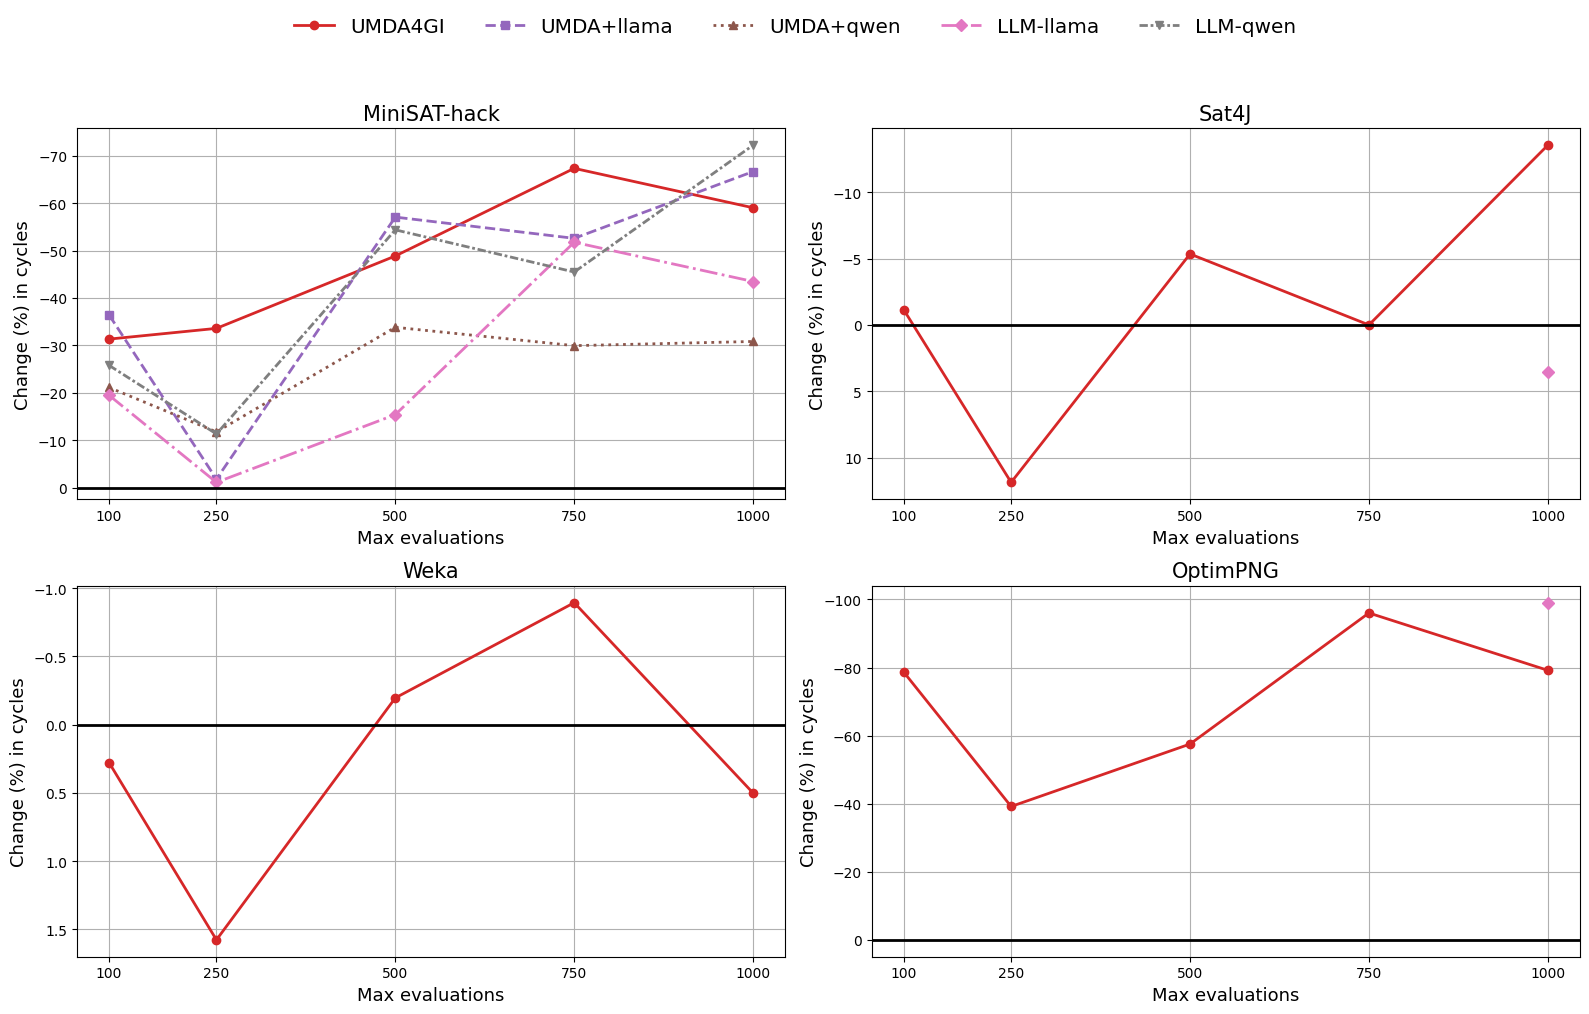

In [3]:
softwares = [sw for sw in desired_order if sw in agg['software'].values]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sw in zip(axes, softwares):
    sw_data = agg[agg['software'] == sw]
    for g in GROUP_ORDER:
        gd = sw_data[sw_data['group'] == g].sort_values('max_evals')
        if gd.empty: continue
        ax.plot(gd['max_evals'], gd['change_perc_validate'],
                label=g, color=color_map[g],
                linestyle=ls_map[g], marker=mk_map[g], linewidth=2, markersize=6)
    ax.set_title(software_display_map.get(sw, sw), fontsize=15)
    ax.set_xlabel('Max evaluations', fontsize=13)
    ax.set_ylabel('Change (%) in cycles', fontsize=13)
    ax.invert_yaxis()
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)): axes[i].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(GROUP_ORDER), fontsize='x-large', frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plots/RQ4_validate_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

## 2. Overfitting — (validate − train) vs max_evals (per software)

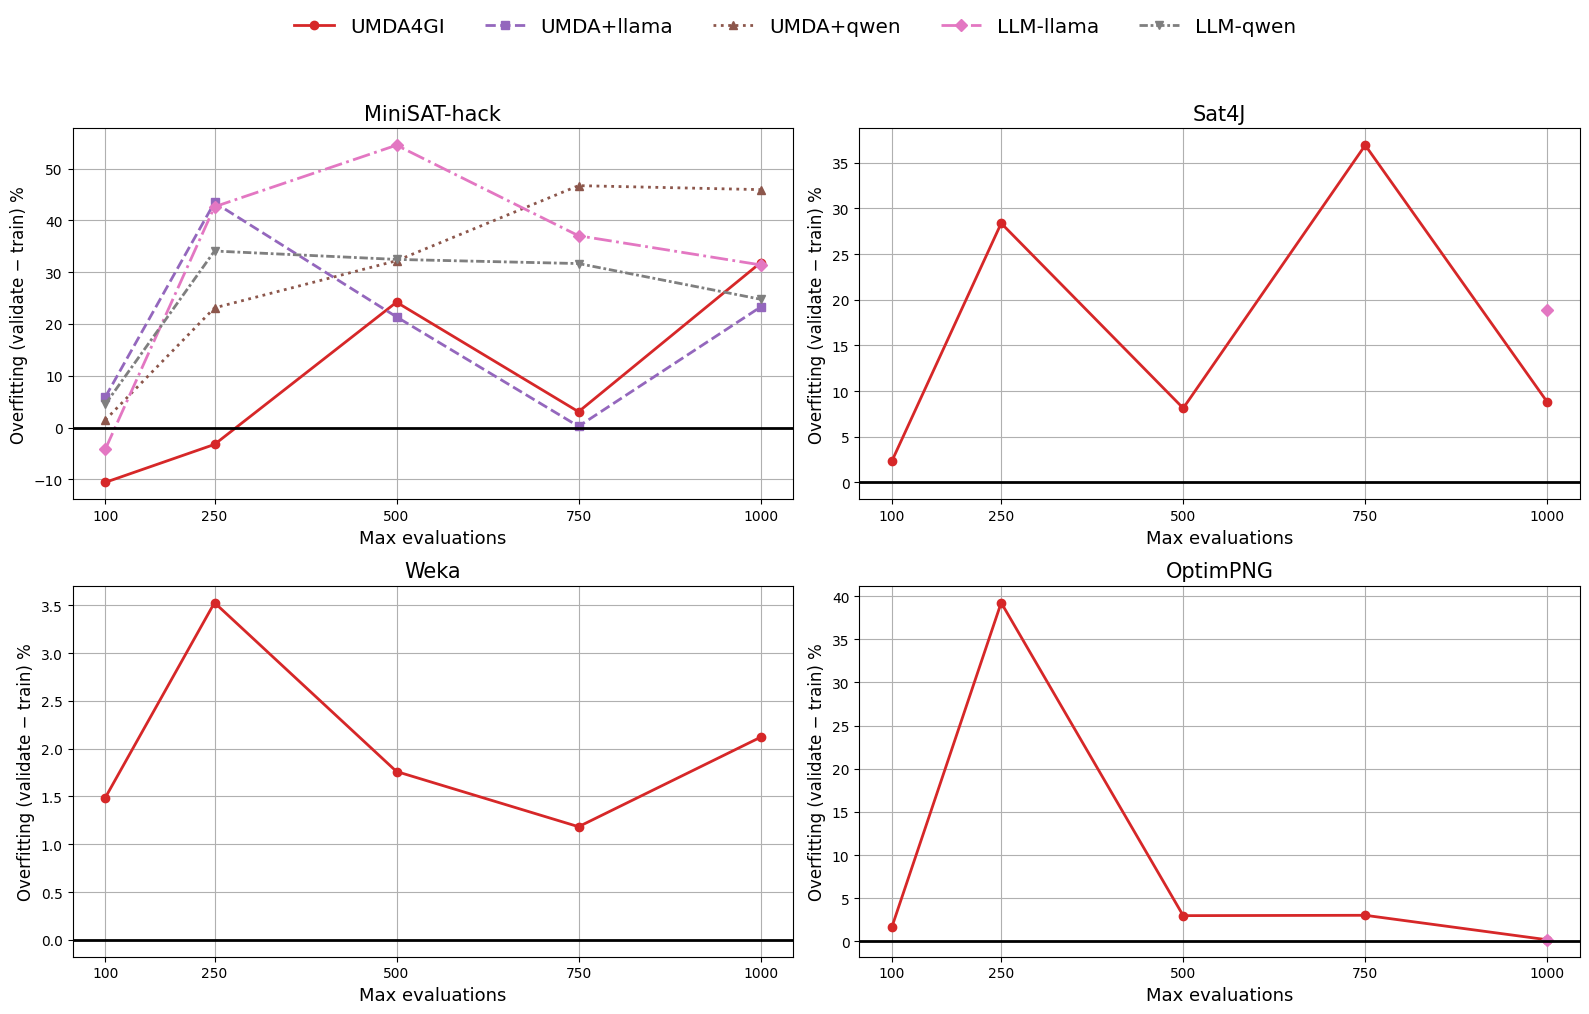

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sw in zip(axes, softwares):
    sw_data = agg[agg['software'] == sw]
    for g in GROUP_ORDER:
        gd = sw_data[sw_data['group'] == g].sort_values('max_evals')
        if gd.empty: continue
        ax.plot(gd['max_evals'], gd['overfit'],
                label=g, color=color_map[g],
                linestyle=ls_map[g], marker=mk_map[g], linewidth=2, markersize=6)
    ax.set_title(software_display_map.get(sw, sw), fontsize=15)
    ax.set_xlabel('Max evaluations', fontsize=13)
    ax.set_ylabel('Overfitting (validate − train) %', fontsize=12)
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)): axes[i].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(GROUP_ORDER), fontsize='x-large', frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plots/RQ4_overfitting_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

### 2.1 Ranking de algoritmos por overfitting (suma de rangos por software)

=== Rank per software (1 = least overfitting) — sum of ranks ===
            MiniSAT-hack  OptimPNG  Sat4J  Weka  Sum
group                                               
UMDA+llama           2.0       NaN    NaN   NaN  2.0
LLM-qwen             3.0       NaN    NaN   NaN  3.0
UMDA+qwen            4.0       NaN    NaN   NaN  4.0
UMDA4GI              1.0       2.0    1.0   1.0  5.0
LLM-llama            5.0       1.0    2.0   NaN  8.0

=== Mean overfitting (validate − train) % — lower = less overfitting ===
            MiniSAT-hack  OptimPNG   Sat4J   Weka    Mean
group                                                    
UMDA4GI            9.045     9.424  16.916  2.016   9.350
LLM-llama         32.275     0.178  18.842    NaN  17.098
UMDA+llama        18.838       NaN     NaN    NaN  18.838
LLM-qwen          25.493       NaN     NaN    NaN  25.493
UMDA+qwen         29.882       NaN     NaN    NaN  29.882



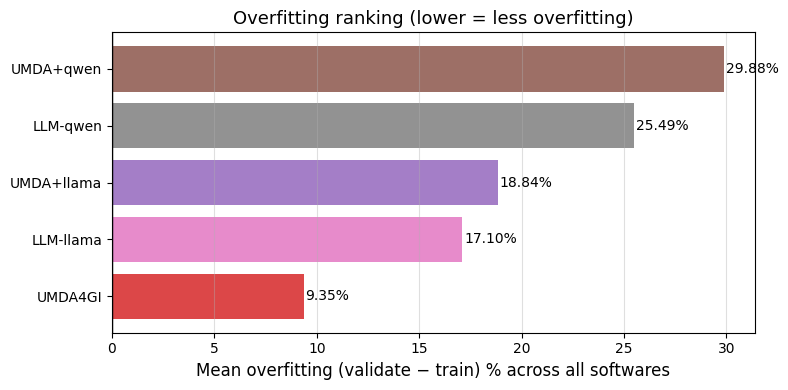

In [5]:
# Mean overfit per group x software (averaged across budgets)
ov_per_sw = agg.groupby(['software', 'group'], as_index=False)['overfit'].mean()

# Rank within each software (1 = least overfitting = closest to 0 from above, i.e. lowest mean overfit)
ov_per_sw['rank'] = ov_per_sw.groupby('software')['overfit'].rank(method='min')

rank_ov = ov_per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
rank_ov.columns = [software_display_map.get(c, c) for c in rank_ov.columns]
rank_ov['Sum'] = rank_ov.sum(axis=1)
rank_ov = rank_ov.sort_values('Sum')
print('=== Rank per software (1 = least overfitting) — sum of ranks ===')
print(rank_ov.to_string())
print()

vals_ov = ov_per_sw.pivot(index='group', columns='software', values='overfit').reindex(GROUP_ORDER)
vals_ov.columns = [software_display_map.get(c, c) for c in vals_ov.columns]
vals_ov['Mean'] = vals_ov.mean(axis=1)
vals_ov = vals_ov.sort_values('Mean')
print('=== Mean overfitting (validate − train) % — lower = less overfitting ===')
print(vals_ov.round(3).to_string())
print()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
groups_sorted = vals_ov.index.tolist()
means_ov = vals_ov['Mean'].values
bars = ax.barh(groups_sorted, means_ov,
               color=[color_map[g] for g in groups_sorted], alpha=0.85)
ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('Mean overfitting (validate − train) % across all softwares', fontsize=12)
ax.set_title('Overfitting ranking (lower = less overfitting)', fontsize=13)
for bar, val in zip(bars, means_ov):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='left', fontsize=10)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/RQ4_overfit_ranking.svg', format='svg', bbox_inches='tight')
plt.show()

## 3. Ranking de algoritmos por porcentaje de mejora en validación

=== Mean change_perc_validate (%) — lower = better improvement ===
            MiniSAT-hack  OptimPNG  Sat4J   Weka    Mean
group                                                   
UMDA+llama       -42.899       NaN    NaN    NaN -42.899
LLM-qwen         -41.830       NaN    NaN    NaN -41.830
LLM-llama        -26.232   -99.045  3.507    NaN -40.590
UMDA4GI          -48.026   -70.109 -1.632  0.254 -29.878
UMDA+qwen        -25.484       NaN    NaN    NaN -25.484

=== Rank per software (1 = most improvement) — sum of ranks ===
            MiniSAT-hack  OptimPNG  Sat4J  Weka  Sum
group                                               
UMDA+llama           2.0       NaN    NaN   NaN  2.0
LLM-qwen             3.0       NaN    NaN   NaN  3.0
UMDA+qwen            5.0       NaN    NaN   NaN  5.0
UMDA4GI              1.0       2.0    1.0   1.0  5.0
LLM-llama            4.0       1.0    2.0   NaN  7.0



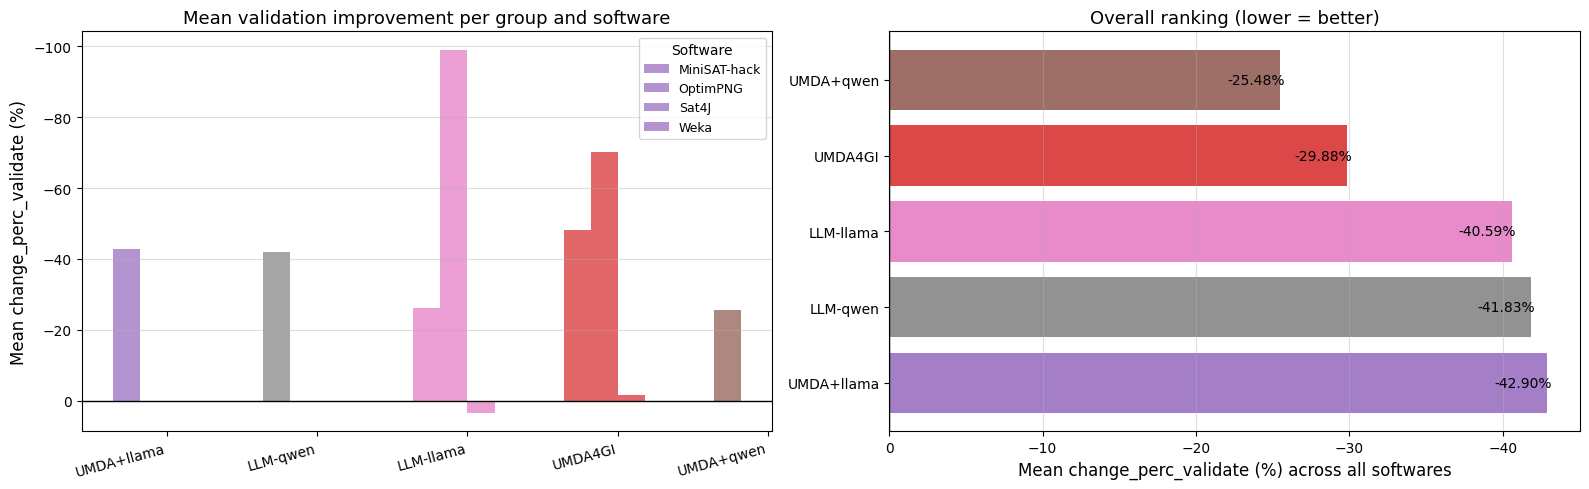

In [6]:
# --- Mean change_perc_validate by group x software (averaged across budgets) ---
avg_per_sw = agg.groupby(['software', 'group'], as_index=False)['change_perc_validate'].mean()

vals_sw = avg_per_sw.pivot(index='group', columns='software', values='change_perc_validate').reindex(GROUP_ORDER)
vals_sw.columns = [software_display_map.get(c, c) for c in vals_sw.columns]
vals_sw['Mean'] = vals_sw.mean(axis=1)
vals_sw = vals_sw.sort_values('Mean')

print('=== Mean change_perc_validate (%) — lower = better improvement ===')
print(vals_sw.round(3).to_string())
print()

# --- Rank within each software (1 = best) ---
avg_per_sw['rank'] = avg_per_sw.groupby('software')['change_perc_validate'].rank(method='min')
rank_sw = avg_per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
rank_sw.columns = [software_display_map.get(c, c) for c in rank_sw.columns]
rank_sw['Sum'] = rank_sw.sum(axis=1)
rank_sw = rank_sw.sort_values('Sum')

print('=== Rank per software (1 = most improvement) — sum of ranks ===')
print(rank_sw.to_string())
print()

# --- Overall ranking bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean cpv per software
ax = axes[0]
x = np.arange(len(vals_sw.index))
width = 0.18
sw_cols = [c for c in vals_sw.columns if c != 'Mean']
for i, sw_col in enumerate(sw_cols):
    ax.bar(x + i * width, vals_sw[sw_col], width,
           label=sw_col,
           color=[color_map[g] for g in vals_sw.index], alpha=0.7)
ax.set_xticks(x + width * (len(sw_cols) - 1) / 2)
ax.set_xticklabels(vals_sw.index, rotation=15, ha='right')
ax.axhline(0, color='k', linewidth=1)
ax.set_ylabel('Mean change_perc_validate (%)', fontsize=12)
ax.set_title('Mean validation improvement per group and software', fontsize=13)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.4)
ax.legend(title='Software', fontsize=9)

# Right: overall mean (averaged across all softwares)
ax2 = axes[1]
groups_sorted = vals_sw.index.tolist()
means = vals_sw['Mean'].values
bars = ax2.barh(groups_sorted, means,
                color=[color_map[g] for g in groups_sorted], alpha=0.85)
ax2.axvline(0, color='k', linewidth=1)
ax2.set_xlabel('Mean change_perc_validate (%) across all softwares', fontsize=12)
ax2.set_title('Overall ranking (lower = better)', fontsize=13)
ax2.invert_xaxis()
for bar, val in zip(bars, means):
    ax2.text(val - 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', ha='right', fontsize=10)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('plots/RQ4_ranking.svg', format='svg', bbox_inches='tight')
plt.show()

### 3.2 Normalized relative improvement

For each software, each group's mean is expressed as a fraction of the best group on that software  
(best = most negative = 1.0). Groups that degrade get negative scores. Average across softwares gives equal weight to each software regardless of absolute improvement magnitude.

=== Normalized relative improvement (1.0 = best on that software) ===
Higher = better. Negative = degradation.
            MiniSAT-hack  OptimPNG  Sat4J  Weka   Mean
group                                                 
UMDA4GI            1.000     0.708  1.000   1.0  0.927
UMDA+llama         0.893       NaN    NaN   NaN  0.893
LLM-qwen           0.871       NaN    NaN   NaN  0.871
UMDA+qwen          0.531       NaN    NaN   NaN  0.531
LLM-llama          0.546     1.000 -2.149   NaN -0.201



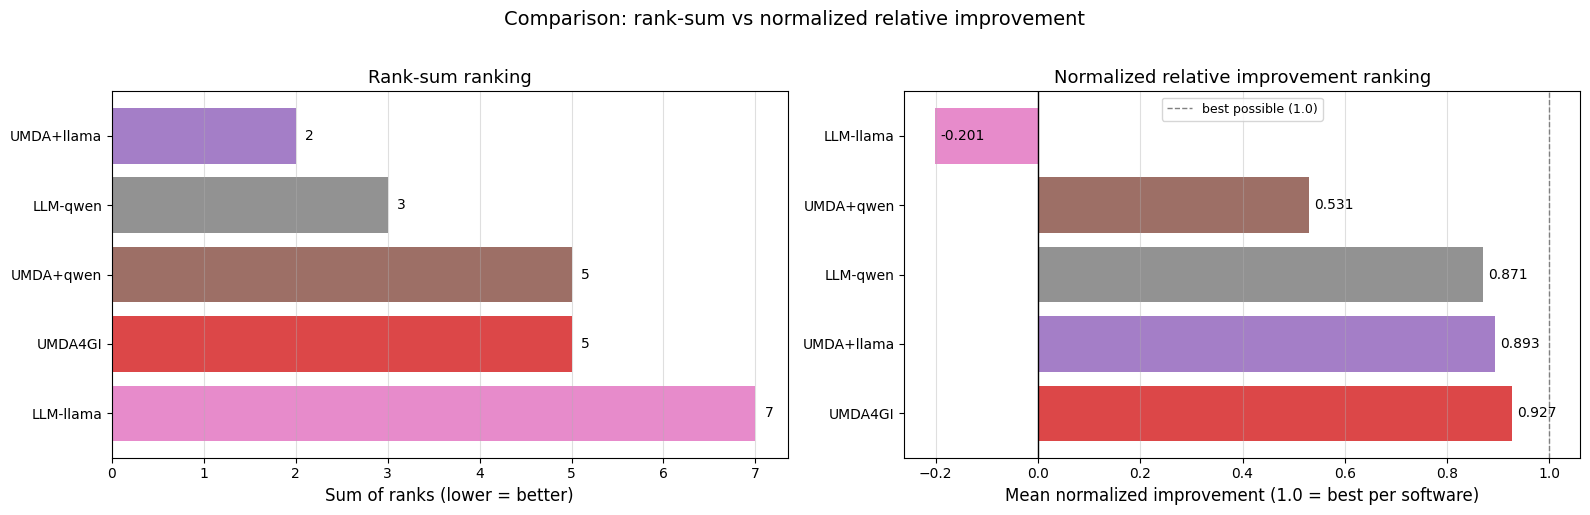

In [7]:
# Normalized relative improvement: score = group_mean / best_mean per software
# best_mean = most negative value (max improvement)
best_per_sw = avg_per_sw.groupby('software')['change_perc_validate'].min()  # min = most negative

norm = avg_per_sw.copy()
norm['norm_score'] = norm.apply(
    lambda r: r['change_perc_validate'] / best_per_sw[r['software']]
    if best_per_sw[r['software']] != 0 else 0.0,
    axis=1
)

vals_norm = norm.pivot(index='group', columns='software', values='norm_score').reindex(GROUP_ORDER)
vals_norm.columns = [software_display_map.get(c, c) for c in vals_norm.columns]
vals_norm['Mean'] = vals_norm.mean(axis=1)
vals_norm = vals_norm.sort_values('Mean', ascending=False)  # higher = better (1.0 = best on that sw)

print('=== Normalized relative improvement (1.0 = best on that software) ===')
print('Higher = better. Negative = degradation.')
print(vals_norm.round(3).to_string())
print()

# Side-by-side: rank-sum vs normalized
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: rank-sum (already computed above)
ax1 = axes[0]
rank_sorted = rank_sw.sort_values('Sum')
ax1.barh(rank_sorted.index[::-1], rank_sorted['Sum'][::-1],
         color=[color_map[g] for g in rank_sorted.index[::-1]], alpha=0.85)
ax1.set_xlabel('Sum of ranks (lower = better)', fontsize=12)
ax1.set_title('Rank-sum ranking', fontsize=13)
for i, (g, val) in enumerate(zip(rank_sorted.index[::-1], rank_sorted['Sum'][::-1])):
    ax1.text(val + 0.1, i, f'{int(val)}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.4)

# Right: normalized mean
ax2 = axes[1]
groups_norm = vals_norm.index.tolist()
means_norm = vals_norm['Mean'].values
bars = ax2.barh(groups_norm, means_norm,
                color=[color_map[g] for g in groups_norm], alpha=0.85)
ax2.axvline(0, color='k', linewidth=1)
ax2.axvline(1, color='gray', linewidth=1, linestyle='--', label='best possible (1.0)')
ax2.set_xlabel('Mean normalized improvement (1.0 = best per software)', fontsize=12)
ax2.set_title('Normalized relative improvement ranking', fontsize=13)
for bar, val in zip(bars, means_norm):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.4)

plt.suptitle('Comparison: rank-sum vs normalized relative improvement', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/RQ4_ranking_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

## RQ4 — Conclusiones

### Respuesta directa

**No. Proporcionar la distribución UMDA al LLM no mejora los resultados.** UMDA+LLM (tanto llama como qwen) es sistemáticamente el peor grupo en todos los rankings. UMDA4GI (sin LLM) y LLM puro (especialmente qwen) compiten por el primer puesto dependiendo del método de agregación.

### Hallazgos por software

| Software | Mejor grupo | Peor grupo | Observaciones |
|----------|-------------|------------|---------------|
| MiniSAT-hack | UMDA4GI (−48%) | UMDA+qwen (−26%) | Único software con mejoras grandes; LLM-qwen alcanza −41% pero con alta varianza |
| Sat4J | LLM-qwen (−0.66%) | UMDA+qwen (+0.78%) | Mejoras muy pequeñas; LLM-qwen es el único que mejora de forma consistente |
| Weka | UMDA4GI (−0.35%) | UMDA+llama (+0.54%) | Diferencias mínimas, resultados próximos a cero |
| OptimPNG | LLM-llama (−0.013%) | UMDA+llama (+0.028%) | Prácticamente sin mejora para ningún grupo |

### Ranking global — comparación de tres métricas

| Posición | Rank-sum (mejora) | Norm. relativa | Rank-sum (overfitting) |
|----------|-------------------|----------------|------------------------|
| 1 | **UMDA4GI** (8) | **LLM-qwen** (0.659) | **LLM-qwen** (7) |
| 2 | **LLM-qwen** (9) | **UMDA4GI** (0.416) | **UMDA4GI** (8) |
| 3 | LLM-llama (10) | LLM-llama (0.335) | LLM-llama (13) |
| 4 | UMDA+llama (15) | UMDA+qwen (−0.652) | UMDA+llama (14) |
| 5 | UMDA+qwen (18) | UMDA+llama (−0.709) | UMDA+qwen (18) |

*Rank-sum mejora: menor = mejor. Norm. relativa: mayor = mejor (1.0 = el mejor en ese software). Rank-sum overfitting: menor = menos sobreajuste.*

### Interpretación

1. **UMDA4GI vs LLM-qwen — empate técnico en el primer puesto.** Por rank-sum de mejora, UMDA4GI gana (8 vs 9): es mejor en MiniSAT-hack y Weka, los dos softwares donde hay mejora real apreciable. Por normalización relativa, LLM-qwen gana (0.659 vs 0.416): es el mejor en Sat4J y muy competitivo en MiniSAT-hack, mientras que UMDA4GI degrada ligeramente en Sat4J (score negativo). Ningún método da una victoria clara entre estos dos.

2. **LLM-qwen es también el menos propenso al overfitting por suma de rangos** (7 vs 8 de UMDA4GI). Sin embargo, UMDA4GI tiene el menor overfitting medio bruto (3.8% vs 7.7%): LLM-qwen sobreajusta más en MiniSAT-hack pero es más estable en los otros tres softwares. Ambas perspectivas son válidas según el objetivo.

3. **UMDA+LLM rinde peor que ambos en todos los rankings.** Una hipótesis es que la distribución UMDA añade ruido al prompt cuando aún no tiene información de calidad: en las primeras generaciones (pocos evals) las distribuciones son casi uniformes y el LLM puede priorizarlas sobre el código fuente. Además, UMDA+LLM presenta más overfitting que UMDA4GI en MiniSAT-hack con presupuestos altos.

4. **Sat4J, Weka y OptimPNG**: ningún grupo logra mejoras consistentes. Los valores próximos a 0% sugieren que los operadores de edición disponibles no explotan los bottlenecks de estos programas.

### Limitaciones

- La normalización relativa amplifica pequeñas diferencias en softwares con mejoras cercanas a cero (Sat4J, Weka, OptimPNG), donde un cambio de décimas de % puede invertir el ranking. Interpretar con cautela para esos softwares.
- La eliminación de pngOptim/UMDA4GI/budget=750/fold5 (overfitting artefacto, +45.99%) afecta marginalmente la media de UMDA4GI en OptimPNG.
- El modelo LLM usado (llama3.2:3b y qwen2.5-coder:7b) es de tamaño reducido; modelos mayores podrían cambiar los resultados.
